# Objectives:

In this notebook, we will clean the data and make it ready for EDA. This process will include, but will not be limited to:
- Dealing with duplicates
- Make sure the dataset's columns are set to the correct data types
- Remove non-transactional records in the dataset
- Dealing with invoice numbers with the letter "A" as prefix
- Removing the "C" in the cancelled invoice numbers and adding a new column to flag cancellations
- Dealing with incorrect values such as zero-priced records
- Dealing with missing values
- Investigating the meaning behind negative quantity
- Confirming if missing values in the Description column can be replaced using stock codes as a reference

# Code:

## Initialization:

In [1]:
import os
os.chdir('..')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.calculators import percent

In [3]:
raw_df = pd.read_csv('data/raw/Online_Retail.csv', encoding='ISO-8859-1')
# Importing the data from Kaggle directly is also an option

In [4]:
df = raw_df.copy()
# This copy is made just in case we want to reset df without loading the dataset again

## Structural Data Cleaning:

### Duplicates:

In [5]:
duplicate_rows = df[df.duplicated()]

Let's see if duplicates are only common in a relatively small number of invoices:

In [6]:
invoices_duplicate_count = duplicate_rows['InvoiceNo'].value_counts()
invoices_count = df['InvoiceNo'][df['InvoiceNo'].isin(duplicate_rows['InvoiceNo'])].value_counts()
pd.concat([invoices_duplicate_count, invoices_count], axis=1)


,count,count
InvoiceNo,,
555524,34,76
547651,31,114
579458,28,126
572103,27,223
574481,27,191
...,...,...
581449,1,19
581450,1,30
581456,1,39


In [7]:
print("Invoices containing duplicate transactions:", len(invoices_duplicate_count))
print("Percentage of invoices containing duplicates with the overall duplicate rows:", percent(len(invoices_duplicate_count), len(duplicate_rows)))

Invoices containing duplicate transactions: 1933
Percentage of invoices containing duplicates with the overall duplicate rows: 36.69%


Even though some invoices have more duplicates than others, there doesn't seem to be a clear pattern since 1933 invoices contain duplicates, and that number represents ~36.7% of the total number of duplicate rows in the dataset.

The data contains 5,268 duplicated rows.\
Duplicate records are either a result of shopping carts having the option to choose the same item with the same quantity separately, or they are system-generated errors.\
Overall, it's impossible to know without the guidance of a stakeholder or without knowing how the system of the online retail store works.\
Even though duplicates only represent ~0.1% of the data, their effect on the EDA process is not guranteed to be minimal. Further inspection is required in EDA. For now, we can flag duplicate rows to be able to investigate them later.

In [8]:
df['Duplicate'] = df.duplicated()

### Datatypes:

In [9]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
Duplicate         bool
dtype: object

The InvoiceDate column is stored as a string data type and not datetime64. Let's change that:

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

C:\Users\micro\AppData\Local\Temp\ipykernel_20128\3633860036.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [11]:
df['InvoiceDate'].sample(10, random_state=142)

128745   2011-03-22 12:27:00
284670   2011-07-31 12:52:00
399875   2011-10-16 15:27:00
352570   2011-09-21 15:43:00
194586   2011-05-18 11:28:00
288748   2011-08-03 12:54:00
476380   2011-11-17 12:11:00
18006    2010-12-08 12:56:00
261706   2011-07-13 11:33:00
483877   2011-11-20 12:53:00
Name: InvoiceDate, dtype: datetime64[us]

---

## Non-transaction entires:

### Bookkeeping Stock Codes:

In [12]:
stockcodes = pd.Series(df['StockCode'].unique())

#### Non-numeric Stock Codes

In [13]:
# Creating a series with only non-numeric stock codes
non_numeric_stockcodes = stockcodes[~stockcodes.str.isdigit()]
print('Non-numeric stock codes:', len(non_numeric_stockcodes))
print('Percentage of non-numeric stock codes:', percent(len(non_numeric_stockcodes), len(stockcodes)))

Non-numeric stock codes: 1124
Percentage of non-numeric stock codes: 27.62%


In [14]:
df_non_numeric_stockcodes = df[df['StockCode'].isin(non_numeric_stockcodes)]
print('Rows with non-numeric stock codes:', len(df_non_numeric_stockcodes))
print('Percentage of transactions with non-numeric stock codes:', percent(len(df_non_numeric_stockcodes), len(df)))

Rows with non-numeric stock codes: 54873
Percentage of transactions with non-numeric stock codes: 10.13%


Even though ~27.6% of stock codes are non-numeric, that shouldn't mean that they should be treated as invalid (e.g. The stock code "85123" shouldn't be any more credible than "85123A" is).

#### Alphabetic Stock Codes

In [15]:
# Creating a series with only alphabetic stock codes
alphabetic_stockcodes = stockcodes[stockcodes.str.isalpha()]
print('Alphabetic stock codes:', len(alphabetic_stockcodes))
print('Percentage of alphabetic stock codes:', percent(len(alphabetic_stockcodes), len(stockcodes)))

Alphabetic stock codes: 12
Percentage of alphabetic stock codes: 0.29%


In [16]:
df_alphabetic_stockcodes = df[df['StockCode'].isin(alphabetic_stockcodes)]
print('Rows with alphabetic stock codes:', len(df_alphabetic_stockcodes))
print('Percentage of transactions with alphabetic stock codes:', percent(len(df_alphabetic_stockcodes), len(df)))

Rows with alphabetic stock codes: 2759
Percentage of transactions with alphabetic stock codes: 0.51%


Let's see which descriptions do they point to and how frequently.

In [17]:
alphabetic_stockcodes_desc = df_alphabetic_stockcodes.groupby('StockCode')['Description']
alphabetic_stockcodes_desc.value_counts().sort_values(ascending=False)

StockCode  Description               
POST       POSTAGE                       1252
DOT        DOTCOM POSTAGE                 709
M          Manual                         571
D          Discount                        77
S          SAMPLES                         63
AMAZONFEE  AMAZON FEE                      34
CRUK       CRUK Commission                 16
DCGSSGIRL  GIRLS PARTY BAG                 13
DCGSSBOY   BOYS PARTY BAG                  11
PADS       PADS TO MATCH ALL CUSHIONS       4
B          Adjust bad debt                  3
m          Manual                           1
Name: count, dtype: int64

In addition to alphabetic stock codes breaking the standard 5-digit numeric or 5-digit + letter convention usually used for actual inventory items, they also point to the descriptions "POSTAGE", "DOTCOM POSTAGE", "Manual" and other descriptions which represent accounting adjustments, shipping fees, or internal entries and don't represent real transactions/purchases.
Therefore, rows with alphabetic stock codes should be removed.

To help us get a better understanding of the data structually, before removal of alphabetic stock codes, let's do a quick check whether alphabetic stock codes are associated with missing customers and whether invoices with alphabetic stock codes contain real transactions within them.

In [18]:
df_alphabetic_stockcodes['CustomerID'].isna().all()

np.False_

In [19]:
df_alphabetic_stockcodes[~df_alphabetic_stockcodes['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,False
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,False
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands,False
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany,False
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
541216,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518.0,Germany,False
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,False
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,False
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,False


It seems that most of these records do have a customer.

In [20]:
alphabetic_stockcodes_invoices = pd.Series(df_alphabetic_stockcodes['InvoiceNo'].unique())
df[df['InvoiceNo'].isin(alphabetic_stockcodes_invoices)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,False
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,False
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,False
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,False
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,False
...,...,...,...,...,...,...,...,...,...
541801,581578,22993,SET OF 4 PANTRY JELLY MOULDS,12,2011-12-09 12:16:00,1.25,12713.0,Germany,False
541802,581578,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,2011-12-09 12:16:00,0.85,12713.0,Germany,False
541803,581578,22908,PACK OF 20 NAPKINS RED APPLES,12,2011-12-09 12:16:00,0.85,12713.0,Germany,False
541804,581578,23215,JINGLE BELL HEART ANTIQUE SILVER,12,2011-12-09 12:16:00,2.08,12713.0,Germany,False


Invoices with alphabetic stock codes can have real transactions within them.

In [21]:
df = df[~df['StockCode'].str.isalpha()]

In [22]:
len(df)

539150

Even though we removed rows with alphabetic stock codes, there might still be some stock codes that have numbers in them and do not represent real transactions/purchases.\
Since normal transactions usually start with an integer, let's check the stock codes that have an alphabetic prefix.

In [23]:
stockcodes = pd.Series(df['StockCode'].unique())

In [24]:
stockcodes[stockcodes.str[0].str.isalpha()]

771               C2
1538    BANK CHARGES
2435        DCGS0076
2533        DCGS0003
2768    gift_0001_40
2780        DCGS0070
2808    gift_0001_50
2835    gift_0001_30
2836    gift_0001_20
3007        DCGS0055
3008        DCGS0072
3009        DCGS0074
3011        DCGS0069
3031        DCGS0057
3188    gift_0001_10
3375        DCGS0004
3700        DCGS0073
3701        DCGS0071
3702        DCGS0068
3703        DCGS0067
3704       DCGS0066P
dtype: str

Stock codes with an alphabetic prefix seem to point to non-transactional records. Therefore, they should be removed.

In [25]:
df = df[~df['StockCode'].str[0].str.isalpha()]

In [26]:
len(df)

538914

---

### Zero-price Records:

Zero-price records would likely represent non-transactional records such as bookkeeping adjustments.
To confirm, let's check the unique descriptions of transactions with a unit price of zero:

In [27]:
df_zero_price = df[df['UnitPrice'] == 0]
print('Transactions with a unit price of zero:', len(df_zero_price))
print('Percentage of transactions with unit prices of zero:', percent(len(df_zero_price), len(df)))

Transactions with a unit price of zero: 2485
Percentage of transactions with unit prices of zero: 0.46%


In [28]:
df_zero_price['Description'].value_counts().head(20)

Description
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
FRENCH BLUE METAL DOOR SIGN 1        9
thrown away                          9
Unsaleable, destroyed.               9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN 4        7
FRENCH BLUE METAL DOOR SIGN No       7
OWL DOORSTOP                         7
FRENCH BLUE METAL DOOR SIGN 3        7
RECIPE BOX PANTRY YELLOW DESIGN      7
??                                   7
Name: count, dtype: int64

Transactions with zero unit price represent promotional items, replacements for a returned item, or bookkeeping entries. Since they do not generate revenue and would distort price-based analysis, they should be removed from the dataset.

In [29]:
df = df[df['UnitPrice'] != 0]

In [30]:
len(df)

536429

For confirmation, let's check if the data contains some system-level bookkeepings by checking some random known bookkeeping descriptions.

In [31]:
bookkeeping_descriptions = ['POST', 'POSTAGE', 'CHECK', 'DAMAGE', '?', 'AMAZON', 'AMAZONFEE', 'FOUND', 'LOST', 'B', 'MANUAL', 'M']

In [32]:
df[df['Description'].str.upper().isin(bookkeeping_descriptions)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate


There are none left.

### Negative-priced Records:

In [33]:
df_negative_price = df[df['UnitPrice'] < 0]
print('Rows with a negative unit price:', len(df_negative_price))
print('Percentage of transactions with a negative unit price:', percent(len(df_negative_price), len(df)))

Rows with a negative unit price: 0
Percentage of transactions with a negative unit price: 0%


Transactions with a negative unit price seem to have already been removed with other non-transactional entries.

---

## Transaction-level Data Cleaning:

### InvoiceNo:

Let's check whether invoices can have transactions with different timestamps:

In [34]:
# Grouping by InvoiceNo to get the unique number of timestamps per invoice
invoice_timestamps_count = df.groupby('InvoiceNo')['InvoiceDate'].nunique()

# Returning the value counts of different timestamps per invoice
invoice_multiple_timestamps = invoice_timestamps_count[invoice_timestamps_count != 1]
invoice_multiple_timestamps.value_counts()

InvoiceDate
2    43
Name: count, dtype: int64

It seems that there are 43 orders that contain transactions with two different timestamps. Meaning that not all transactions that are within the same invoice happen at the same time.

How much is the difference in time? Are they only minutes away? Let's see:

In [35]:
# Grouping invoice dates by invoice numbers then taking the difference between each timestamp and the one before and summing all differences
df.groupby('InvoiceNo')['InvoiceDate'].diff().sum()

Timedelta('0 days 00:43:00')

The sum of all same-invoice timestamps differences is 43 minutes, which is the same amount of invoices with different timestamps. Meaning that whenever there is a difference in the timestamps within the same invoice, it is only 1 minute.

From the previous notebook, there seemed to be 3 invoice numbers starting with the letter "A". Let's check their rows in the dataset.

In [36]:
#Checking the rows in the df where the invoice number starts with an "A"
df[df['InvoiceNo'].isin(df['InvoiceNo'].apply(lambda x: x if x[0] == 'A' else None).dropna())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate


The rows with an invoice number starting with the letter "A" seem to have been implicitely removed with other non-transactional entries.

---

### InvoiceNo Cancellation:

The invoice numbers starting with the letter "C" represent cancellations.\
Since we've established from the previous notebook that invoices that resemble cancellations don't repeat without the "C" prefix, we can safely remove the "C" letter from cancellations to have better consistency with invoice numbers.

But before we remove the "C", let's create a new column to flag cancellations.

In [37]:
df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
130143,547413,48187,DOORMAT NEW ENGLAND,2,2011-03-23 09:43:00,7.95,13475.0,United Kingdom,False,False
503933,578940,22423,REGENCY CAKESTAND 3 TIER,5,2011-11-27 13:18:00,24.96,NaN,United Kingdom,False,False
167034,550968,22989,SET 2 PANTRY DESIGN TEA TOWELS,6,2011-04-21 16:59:00,3.25,14961.0,United Kingdom,False,False
231880,557289,23201,JUMBO BAG ALPHABET,1,2011-06-19 12:58:00,2.08,16880.0,United Kingdom,False,False
222391,556426,23238,SET OF 4 KNICK KNACK TINS LONDON,4,2011-06-10 13:18:00,4.15,16729.0,United Kingdom,False,False


Now, let's remove the "C":

In [38]:
df['InvoiceNo'] = df['InvoiceNo'].apply(lambda invoice_number: invoice_number[1:] if invoice_number.startswith('C') else invoice_number)

---

### Negative Quantities:

In [39]:
df_negative_quantity = df[df['Quantity'] < 0]
print('Rows with a negative quantity:', len(df_negative_quantity))
print('Percentage of transactions with a negative quantity:', percent(len(df_negative_quantity), len(df)))

Rows with a negative quantity: 8704
Percentage of transactions with a negative quantity: 1.62%


~1.62% of the transactions contain a negative quantity.

Let's see what is the ratio of transactions that contain negative quantities to be a cancelled transaction.

In [40]:
df_negative_quantity_cancelled = df_negative_quantity[df_negative_quantity['Cancelled']]
print('Rows with negative quantites and cancelled transactions:', len(df_negative_quantity_cancelled))
print('Percentage of transactions with negative quantites that are cancelled:', percent(len(df_negative_quantity_cancelled), len(df_negative_quantity)))
print('Percentage of all transactions that have a negative quantity and are cancelled:', percent(len(df_negative_quantity_cancelled), len(df)))

Rows with negative quantites and cancelled transactions: 8704
Percentage of transactions with negative quantites that are cancelled: 100.0%
Percentage of all transactions that have a negative quantity and are cancelled: 1.62%


In [41]:
(df[df['Cancelled']]['Quantity'] < 0).all()

np.True_

All transactions with a negative quantity are a cancellation and all cancellation records have a negative quantity. This justifies the negative sign as a mathematical flag for cancellations for calculating net revenue.\
Therefore, negative quantities should be kept as is.

---

## Product labelling Inconsistencies:

### Description Standardization:

Let's check if there are still stock codes that correspond to multiple descriptions:

In [42]:
stockcode_descriptions = df.groupby('StockCode')['Description'].unique()
diverse_stockcode_descriptions = stockcode_descriptions[stockcode_descriptions.str.len() > 1]
diverse_stockcode_descriptions_rows = df[df['StockCode'].isin(diverse_stockcode_descriptions.index)]
print('Number of unique stock codes that point to more than one description:', len(diverse_stockcode_descriptions))
print('Percentage of unique stock codes that point to more than one description:', percent(len(diverse_stockcode_descriptions), len(stockcode_descriptions)))
print('Transactions with stock codes that point to more than one description:', len(diverse_stockcode_descriptions_rows))
print('Percentage of transactions with stock codes that point to more than one description:', percent(len(diverse_stockcode_descriptions_rows), len(df)))

Number of unique stock codes that point to more than one description: 220
Percentage of unique stock codes that point to more than one description: 5.62%
Transactions with stock codes that point to more than one description: 48637
Percentage of transactions with stock codes that point to more than one description: 9.07%


~6% of the unique stock codes point to more than one description.\
\~9% of the transactions have a stock code that points to more than one description.\
Let's check a sample of what descriptions do those stock codes point to:

In [43]:
diverse_stockcode_descriptions.sample(10, random_state=142)

StockCode
22932     [BAKING MOULD TOFFEE CUP CHOCOLATE, BAKING MOU...
23306     [SET OF 36 DOILIES PANTRY DESIGN, SET OF 36 PA...
84946     [ANTIQUE SILVER TEA GLASS ETCHED, ANTIQUE SILV...
23020     [GLASS  SONGBIRD STORAGE JAR, GLASS SONGBIRD S...
21507     [ELEPHANT, BIRTHDAY CARD, , ELEPHANT BIRTHDAY ...
23253     [16 PIECE CUTLERY SET PANTRY DESIGN, 16 PC CUT...
23484     [HEART TRELLISTRIPLE T-LIGHT HOLDER, HEART TRE...
17107D    [FLOWER FAIRY,5 SUMMER B'DRAW LINERS, FLOWER F...
23091     [ZINC HERB GARDEN CONTAINER, METAL HERB GERDEN...
22999     [TRAVEL CARD WALLET RETRO PETALS, TRAVEL CARD ...
Name: Description, dtype: object

The descriptions that have the same stock code seem to have the same meaning.\
We may assume that the most frequent description associated with each stockcode represents the canonical product name.\
So, let's standardize descriptions by replacing each with the most frequent description associated with each stockcode:

In [44]:
canonical_descriptions = (
    df.groupby('StockCode')['Description']
        .agg(lambda x: x.value_counts().idxmax())
)
standardized_descriptions = df['StockCode'].map(canonical_descriptions)
df['Description'] = standardized_descriptions

For confirmation, let's check number of unique values of both columns:

In [45]:
df[['StockCode', 'Description']].nunique()

StockCode      3914
Description    3789
dtype: int64

Some descriptions seem to also have multiple stock codes, let's investigate further:

In [46]:
description_stockcodes = df.groupby('Description')['StockCode'].unique()
diverse_description_stockcodes = description_stockcodes[description_stockcodes.str.len() > 1]

In [47]:
diverse_description_stockcodes.sample(10, random_state=142)

Description
FAIRY CAKE DESIGN UMBRELLA                                            [15060B, 15060b]
75 GREEN FAIRY CAKE CASES                                             [84989a, 84989A]
PINK FLOWERS RABBIT EASTER                                            [35909B, 35910B]
FRENCH FLORAL CUSHION COVER                                             [20840, 20837]
RED RETROSPOT UMBRELLA                                                [85014B, 85014b]
PINK FAIRY CAKE CUSHION COVER                                         [47586A, 47585A]
COLUMBIAN CANDLE ROUND                                                  [72130, 72128]
METAL SIGN,CUPCAKE SINGLE HOOK        [82613B, 82613C, 82613A, 82613b, 82613c, 82613a]
SET/3 OCEAN SCENT CANDLE JEWEL BOX                                    [72807B, 72807b]
S/4 PINK FLOWER CANDLES IN BOWL                                       [85040A, 85040a]
Name: StockCode, dtype: object

Since we do not have a dictionary of the retailer's products and their stock codes and in order for stock codes and descriptions to both be unique identifiers for products, only the most frequent stock code will be kept. However, this decision will not weaken analytic claim because we won't be investigating the meaning of stock codes or product identification in this project.

In [48]:
canonical_stockcodes = (
    df.groupby('Description')['StockCode']
        .agg(lambda x: x.value_counts().idxmax())
)
standardized_descriptions = df['Description'].map(canonical_stockcodes)
df['StockCode'] = standardized_descriptions

In [49]:
df[['StockCode', 'Description']].nunique()

StockCode      3789
Description    3789
dtype: int64

---

## Incorrect/Missing Values:

### Unspecified Countries:

Let's check what percentage of the data is represented by rows with an unspecified country.

In [50]:
df_unspecified_country = df[df['Country'] == 'Unspecified']
print('Rows with transactions with an unspecified country:', len(df_unspecified_country))
print('Percentage of transactions with an unspecified country:', percent(len(df_unspecified_country), len(df)))

Rows with transactions with an unspecified country: 446
Percentage of transactions with an unspecified country: 0.08%


Only ~0.08% of the transactions contain an unspecified country.

Furthermore, let's see if transactions with an unspecified country have anything to do with customer ID:

In [51]:
df_unspecified_country['CustomerID'].value_counts()

CustomerID
12743.0    134
16320.0     56
14265.0     31
12363.0     23
Name: count, dtype: int64

Transactions with an unspecified country seem to be done by only 4 customers.

In [52]:
df_unspecified_country['CustomerID'].value_counts().sum()

np.int64(244)

When summing up the numbers of appearances of all those customers (244), they are lesser than the total number of transactions with an unspecified country (422), meaning that the transactions with an unspecified country contain missing customer IDs.

Let's see the invoices of transactions with an unspecified country:

In [53]:
df_unspecified_country['InvoiceNo'].value_counts()

InvoiceNo
561658    83
559521    72
565303    66
561661    51
552695    47
578539    34
576646    19
549687    16
564051    16
559929    15
553857    11
557499     9
563947     7
Name: count, dtype: int64

The unique invoice numbers in transactions with an unspecified country are too many for there to be a clear pattern.

Let's check a sample of transactions with an unspecified country:

In [54]:
df_unspecified_country.sample(10, random_state=142)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
262995,559929,16161P,WRAP ENGLISH ROSE,25,2011-07-14 09:10:00,0.42,14265.0,Unspecified,False,False
323419,565303,22437,SET OF 9 BLACK SKULL BALLOONS,10,2011-09-02 12:17:00,0.85,NaN,Unspecified,False,False
282740,561658,20886,BOX OF 9 PEBBLE CANDLES,1,2011-07-28 16:06:00,1.95,12743.0,Unspecified,False,False
184553,552695,22707,WRAP MONSTER FUN,25,2011-05-10 15:31:00,0.42,16320.0,Unspecified,False,False
323436,565303,21912,VINTAGE SNAKES & LADDERS,2,2011-09-02 12:17:00,3.75,NaN,Unspecified,False,False
323409,565303,22530,MAGIC DRAWING SLATE DOLLY GIRL,2,2011-09-02 12:17:00,0.42,NaN,Unspecified,False,False
257266,559521,23242,TREASURE TIN BUFFALO BILL,1,2011-07-08 16:26:00,2.08,NaN,Unspecified,False,False
323392,565303,22904,CALENDAR PAPER CUT DESIGN,1,2011-09-02 12:17:00,2.95,NaN,Unspecified,False,False
257236,559521,22992,REVOLVER WOODEN RULER,5,2011-07-08 16:26:00,1.95,NaN,Unspecified,False,False
282793,561658,23202,JUMBO BAG VINTAGE LEAF,1,2011-07-28 16:06:00,2.08,12743.0,Unspecified,False,False


Since they seem to be normal transactional records, the records with "unspecified" as the country could be the result of the shipping address location of such transactions was not recognized as a country by the system database. But since they seem to be normal transactional records, they will be kept.

---

### Missing Descriptions:

Let's check what percentage of the data is represented by rows with a missing description.

In [55]:
missing_desc_rows = df[df['Description'].isna()]
print('Rows with a missing description:', len(missing_desc_rows))
print('Percentage of transactions with a missing description:', percent(len(missing_desc_rows), len(df)))

Rows with a missing description: 0
Percentage of transactions with a missing description: 0%


There seems to be no rows with missing description left as a result of the previous cleaning process.

---

### Missing Customer IDs:

Let's check what percentage of the data is represented by rows with a missing customer ID.

In [56]:
df_missing_customer = df[df['CustomerID'].isna()]
print('Rows with a missing customer ID:', len(df_missing_customer))
print('Percentage of transactions with a missing customer ID:', percent(len(df_missing_customer), len(df)))

Rows with a missing customer ID: 131553
Percentage of transactions with a missing customer ID: 24.52%


~25% of the transactions don't have a customer ID.

In [57]:
# Getting the value counts of countries that have a missing customer ID in the same row:
missing_customer_country_counts = df_missing_customer['Country'].value_counts().rename('Count')

# Getting the proportions of each country's occurrences with a missing customer ID:
missing_customer_country_percents = (df_missing_customer['Country'].value_counts() / df['Country'].value_counts()).dropna().rename('Proportion')

# Concatenating both series in one dataframe for better visualization:
pd.concat([missing_customer_country_counts, missing_customer_country_percents], axis=1)

,Count,Proportion
Country,,
United Kingdom,130099,0.264787
EIRE,693,0.085863
Hong Kong,280,1.000000
Unspecified,202,0.452915
Switzerland,125,0.063516
France,66,0.008016
Israel,47,0.158249
Portugal,39,0.026441
Bahrain,2,0.105263


Countries with the highest rate of missing customer ID:\
100% of the transactions from Hong Kong don't have a customer ID (284 rows).\
~45% of the transactions that have an unspecified country don't have a customer ID (202 rows).\
\~27% of the transactions from the UK don't have a customer ID. (130,099 rows).

Next up let's check for the correlation between a missing customer ID and timestamp features.
Starting with the year:

In [58]:
(df_missing_customer['InvoiceDate'].dt.year.value_counts() / df['InvoiceDate'].dt.year.value_counts()).sort_values(ascending=False)

InvoiceDate
2010    0.363669
2011    0.235176
Name: count, dtype: float64

23.5% of the transactions in the year 2011 don't have a customer ID.\
36.4% of the transactions in the year 2010 don't have a customer ID.\
No clear pattern or correlation.

What about months?

In [59]:
(df_missing_customer['InvoiceDate'].dt.month.value_counts() / df['InvoiceDate'].dt.month.value_counts()).sort_values(ascending=False)

InvoiceDate
1     0.373898
12    0.342297
7     0.300010
2     0.259834
6     0.239669
3     0.236687
11    0.223560
4     0.217067
5     0.212794
8     0.212558
9     0.184442
10    0.161530
Name: count, dtype: float64

There seems to be no clear patterns regarding missing customer ids and timestamp features.

Let's see if transactions that have a missing customer ID may have a present customer ID in another transaction within the same invoice:

In [60]:
df_notmissing = df[df['CustomerID'].notna()]

In [61]:
# Checking if there are invoice numbers in df_missing that are also present in df_notmissing
len(df_missing_customer[df_missing_customer['InvoiceNo'].isin(df_notmissing['InvoiceNo'])])

0

Wherever a customer ID is missing, it is also missing in all other transactions in that same invoice.

The missing customer IDs in the data are likely because of guest-ordering or incomplete order details which is not abnormal for this kind of data.\
The rows with missing customer IDs will be kept for non-customer-related EDA.

---

## Outlier Assessment & Treatment:

Note: In this section of the data cleaning notebook I'll be figuring out whether extreme values are valid transactions or not. However, their validity cannot be established conclusively without additional business context, such as a product catalogue, historical pricing records, inventory constraints, source-system rules, or guidance from a knowledgeable stakeholder. Statistical thresholds are therefore used only to identify records for investigation, not to classify them automatically as invalid.

Let's check if there are outliers in the dataset.

In [62]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536429.000000,536429,536429.000000,404876.000000
mean,9.889409,2011-07-04 18:13:51.924933,3.283967,15295.253282
min,-80995.000000,2010-12-01 08:26:00,0.030000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13969.000000
50%,3.000000,2011-07-20 12:14:00,2.080000,15159.000000
75%,10.000000,2011-10-19 11:53:00,4.130000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,215.967683,NaN,4.497147,1710.404209


From the difference between the 100th and 75th percentile values, as well as the difference between the 25th and 0th percentile values in Quantity, the Quantiy and UnitPrice columns likely contain outliers, let's investigate further.

### Quantity Outliers:

In [63]:
df['Quantity'].describe()

count    536429.000000
mean          9.889409
std         215.967683
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Since they have different meanings, positive and negative quantity outliers should be processed separately.

In [64]:
df_positive_quantity = df[df['Quantity'] > 0]

<Axes: ylabel='Quantity'>

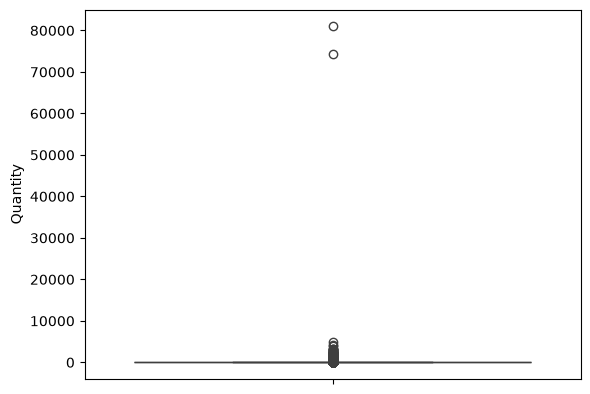

In [65]:
sns.boxplot(df_positive_quantity['Quantity'])

Let's try to plot a log-transformed version of the positive quantity values.

In [66]:
log_positive_quantity = np.log1p(df_positive_quantity['Quantity'])

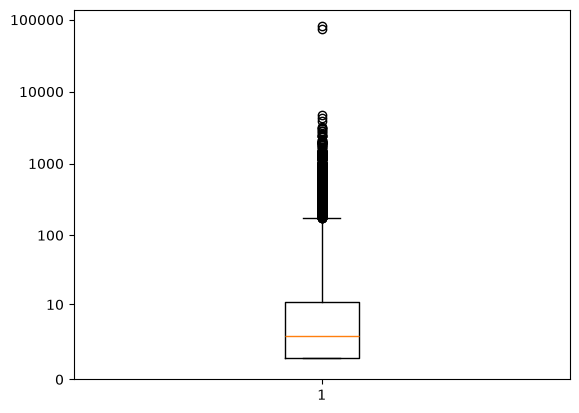

In [67]:
fig, ax = plt.subplots()
ax.boxplot(log_positive_quantity)

ticks = [0, 10, 100, 1000, 10000, 100000]
log_tick_positions = np.log1p(ticks)

ax.set_yticks(log_tick_positions)
ax.set_yticklabels([str(val) for val in ticks])

plt.show()

In [68]:
quantiles = [0.9, 0.95, 0.99, 0.995, 0.999, 1]
df_positive_quantity['Quantity'].quantile(quantiles)

0.900       24.000
0.950       30.000
0.990      100.000
0.995      160.000
0.999      436.416
1.000    80995.000
Name: Quantity, dtype: float64

The difference between the 99.9th percentile and the maximum value strongly confirms a right-skewed distribution of positive quantity. Therefore, the threshold for positive quantity outliers should be 500.

In [69]:
df_positive_quantity_outliers = df_positive_quantity[df_positive_quantity['Quantity'] >= 500].sort_values(by='Quantity', ascending=False)
print("Rows with outlier positive quantity", len(df_positive_quantity_outliers))

Rows with outlier positive quantity 435


In [70]:
df_positive_quantity_outliers.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,False
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,False
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,False,False
206121,554868,22197,POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,False,False
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,False,False
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,False,False
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,False,False
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,False,False
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom,False,False
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom,False,False


The top two rows in quantity are suspicious and should be investigated. The rest, however, look like they are genuine bulk-purchases. The customer 15749 bought the same product with the same quantity, which indicates recurring wholesale purchases.\
We already know that many customers of the company are wholesalers, which would explain the quantity outliers. But just to confirm, let's investigate more.

In [71]:
df[df['Quantity'].abs().isin([80995, 74215])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,False
61624,541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,False,True
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,False
540422,581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,False,True


Both purchases were cancelled a few minutes later.\
Since the dataset doesn't provide reasons for cancellations, it is not possible to determine whether they represent genuine orders that were cancelled or wrong entries that were subsequently corrected. Therefore those high-quantity transactions were likely bought by wholesalers and should be retained rather than classified as invalid.

Let's check if negative quantities contain any extreme outliers.

In [72]:
# Absolute value to be able to log-transform
df_negative_quantity = df[df['Quantity'] < 0]
df_negative_quantity['Quantity'] = df_negative_quantity['Quantity'].abs()

In [73]:
log_negative_quantity = np.log1p(df_negative_quantity['Quantity'])

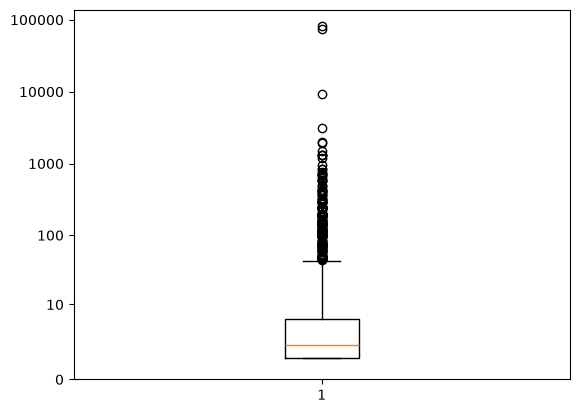

In [74]:
fig, ax = plt.subplots()
ax.boxplot(log_negative_quantity)

ticks = [0, 10, 100, 1000, 10000, 100000]
log_tick_positions = np.log1p(ticks)

ax.set_yticks(log_tick_positions)
ax.set_yticklabels([str(val) for val in ticks])

plt.show()

In [75]:
quantiles = [0.9, 0.95, 0.99, 0.995, 0.999, 1]
df_negative_quantity['Quantity'].quantile(quantiles)

0.900       20.00
0.950       36.00
0.990      180.00
0.995      293.82
0.999     1296.00
1.000    80995.00
Name: Quantity, dtype: float64

The distribution of negative quantities seems to be left-skewed (not right-skewed because what we see are the absolute values of negative quantities).\
For a fair comparison, we should use the same threshold for negative quantity outliers as we did for positive quantity.

In [76]:
df_negative_quantity_outliers = df_negative_quantity[df_negative_quantity['Quantity'] >= 500].sort_values(by='Quantity', ascending=False)
print("Rows with outlier positive quantity", len(df_negative_quantity_outliers))

Rows with outlier positive quantity 26


In [77]:
df_negative_quantity_outliers.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
540422,581484,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,False,True
61624,541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,False,True
4287,536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,False,True
160145,550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:08:00,2.10,15749.0,United Kingdom,False,True
160144,550456,21175,GIN + TONIC DIET METAL SIGN,2000,2011-04-18 13:08:00,1.85,15749.0,United Kingdom,False,True
160143,550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:08:00,2.55,15749.0,United Kingdom,False,True
224419,556522,22920,HERB MARKER BASIL,1515,2011-06-13 11:21:00,0.55,16938.0,United Kingdom,False,True
160142,550456,47566B,TEA TIME PARTY BUNTING,1300,2011-04-18 13:08:00,2.55,15749.0,United Kingdom,False,True
390548,570556,20971,PINK BLUE FELT CRAFT TRINKET BOX,1296,2011-10-11 11:10:00,1.06,16029.0,United Kingdom,True,True
390544,570556,20971,PINK BLUE FELT CRAFT TRINKET BOX,1296,2011-10-11 11:10:00,1.06,16029.0,United Kingdom,False,True


Apart from the top 2 transactions which we already decided to keep, the rest seems to be normal bulk-purchases by wholesaler customers and therefore should be kept.

---

### UnitPrice Outliers:

<Axes: ylabel='UnitPrice'>

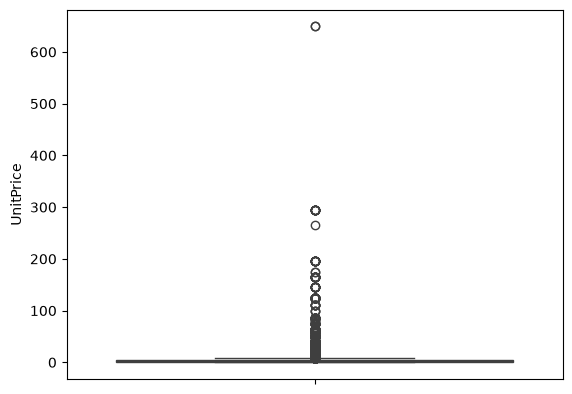

In [78]:
sns.boxplot(df['UnitPrice'])

Let's log-transform for a better boxplot.

In [79]:
log_unitprice = np.log1p(df['UnitPrice'])

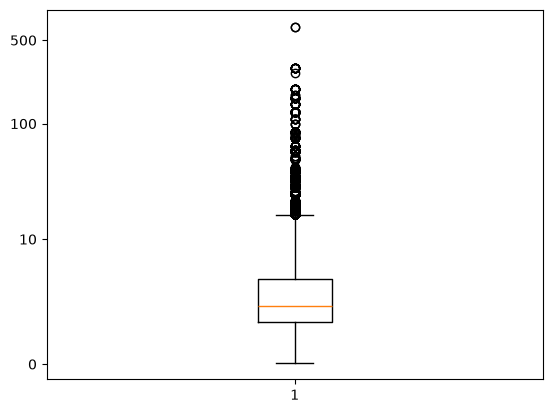

In [80]:
fig, ax = plt.subplots()
ax.boxplot(log_unitprice)

ticks = [0, 10, 100, 500]
log_tick_positions = np.log1p(ticks)

ax.set_yticks(log_tick_positions)
ax.set_yticklabels([str(val) for val in ticks])

plt.show()

In [81]:
quantiles = [0.9, 0.95, 0.99, 0.995, 0.999, 1]
df['UnitPrice'].quantile(quantiles)

0.900      7.65
0.950      9.95
0.990     16.63
0.995     19.96
0.999     34.00
1.000    649.50
Name: UnitPrice, dtype: float64

There is a big difference between the maximum value and the 99.9th percentile. Let's check the top 10 transactions in terms of unit price.

In [82]:
df.sort_values(by='UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
222682,556446,22502,PICNIC BASKET WICKER SMALL,1,2011-06-10 15:33:00,649.5,15098.0,United Kingdom,False,False
222680,556444,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom,False,False
133994,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452.0,United Kingdom,False,False
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452.0,United Kingdom,False,False
87141,543632,22655,VINTAGE RED KITCHEN CABINET,-1,2011-02-10 16:22:00,295.0,14842.0,United Kingdom,False,True
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973.0,United Kingdom,False,False
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015.0,United Kingdom,False,False
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607.0,United Kingdom,False,False
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406.0,United Kingdom,False,False
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842.0,United Kingdom,False,False


For a wider view of unit prices, let's check the top 10 products in terms of unit price.

In [83]:
df.drop_duplicates('UnitPrice').sort_values(by='UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Duplicate,Cancelled
222680,556444,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom,False,False
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145.0,United Kingdom,False,False
51674,540652,22655,VINTAGE RED KITCHEN CABINET,-1,2011-01-10 15:04:00,265.5,17406.0,United Kingdom,False,True
110843,545698,22826,LOVE SEAT ANTIQUE WHITE METAL,1,2011-03-06 14:44:00,195.0,15572.0,United Kingdom,False,False
25168,538354,22826,LOVE SEAT ANTIQUE WHITE METAL,2,2010-12-10 15:45:00,175.0,16873.0,United Kingdom,False,False
246,536392,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,1,2010-12-01 10:29:00,165.0,13705.0,United Kingdom,False,False
19429,537859,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,2,2010-12-08 16:11:00,145.0,14030.0,United Kingdom,False,False
28866,538662,22655,VINTAGE RED KITCHEN CABINET,2,2010-12-13 15:44:00,125.0,15159.0,United Kingdom,False,False
61549,541426,22823,CHEST NATURAL WOOD 20 DRAWERS,4,2011-01-18 08:44:00,110.0,18233.0,United Kingdom,False,False
72653,542255,22833,HALL CABINET WITH 3 DRAWERS,1,2011-01-26 16:43:00,100.0,NaN,United Kingdom,False,False


The highest unit prices are associated with plausible product descriptions rather than bookkeeping or non-product entries. Additionally, the same stock codes retain consistent unit prices across transactions with different quantities, indicating that the values represent product-level prices rather than invoice totals. Although their absolute validity cannot be confirmed without external product information, no internal evidence suggests that they are erroneous. They will therefore be retained without modification.

---

# Exporting the Cleaned Dataset:

In [84]:
df.to_csv('data/processed/Online_Retail_cleaned.csv', index=False)

In [85]:
df.to_parquet('data/processed/Online_Retail_cleaned.parquet', index=False)

---